# Task 2.1: Dataset Selection and Setup

## Reproducibility Header
- Seeds used throughout the experiments: `11, 23, 42, 57, 89`
- Toy dataset: `make_moons(n_samples=1200, noise=0.22, random_state=42)`
- Train/validation/test split: `60/20/20`, stratified by label
- Training-only label flips: `12%`
- Feature preprocessing: `StandardScaler` fitted on the training split only
- Kernel approximation: `RBFSampler`, with `gamma` chosen from `{0.5, 1.0, 2.0}` on validation

I picked `make_moons` because it is a clean way to build a small nonlinear binary-classification problem where mislabeled points are easy to inject and easy to visualize. That makes it a reasonable toy testbed for this paper, because the paper's main claim is about online SVM robustness when some points are so badly misclassified that they should stop influencing the model. The limitation is obvious: my dataset is synthetic, only two-dimensional, and much smaller than the paper's real benchmark problems, so I can only reproduce the mechanism, not the original scale.

The preprocessing steps are simple and fixed across all later notebooks: split the data, flip 12% of the training labels only, standardize using training statistics, then apply an RBF feature map so the online linear learner can approximate a nonlinear separator.

In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEEDS = [11, 23, 42, 57, 89]
DATA_NOISE = 0.22
LABEL_FLIP_RATE = 0.12
N_SAMPLES = 1200
TEST_SIZE = 0.20
VAL_SIZE = 0.20
GAMMA_GRID = [0.5, 1.0, 2.0]
SELECTED_GAMMA = 2.0
N_COMPONENTS = 500
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
FULL_S = -1.0
FAILURE_S = 0.25
PAPER_BANANA_ACCURACY = 89.84

cwd = Path.cwd()
if (cwd / "results").exists() and (cwd / "data").exists():
    PARTB_DIR = cwd
elif (cwd / "partB").exists():
    PARTB_DIR = cwd / "partB"
else:
    PARTB_DIR = cwd
RESULTS_DIR = PARTB_DIR / "results"
DATA_DIR = PARTB_DIR / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_dataset(seed, label_flip_rate=LABEL_FLIP_RATE, data_noise=DATA_NOISE):
    X, y = make_moons(n_samples=N_SAMPLES, noise=data_noise, random_state=42)
    X_train, X_temp, y_train_clean, y_temp = train_test_split(
        X, y, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=seed
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=seed
    )

    rng = np.random.default_rng(seed)
    flip_count = int(label_flip_rate * len(y_train_clean))
    flip_idx = np.sort(rng.choice(len(y_train_clean), size=flip_count, replace=False))

    y_train_observed = y_train_clean.copy()
    y_train_observed[flip_idx] = 1 - y_train_observed[flip_idx]
    was_flipped = np.zeros(len(y_train_clean), dtype=bool)
    was_flipped[flip_idx] = True

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        "seed": seed,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_clean": y_train_clean,
        "y_train_observed": y_train_observed,
        "y_val": y_val,
        "y_test": y_test,
        "was_flipped": was_flipped,
        "scaler": scaler,
    }


def validate_gamma(seeds=SEEDS, gammas=GAMMA_GRID, s=FULL_S):
    rows = []
    for gamma in gammas:
        for seed in seeds:
            split = build_dataset(seed)
            result = train_filtered_online_svm(
                split,
                gamma=gamma,
                s=s,
                n_components=N_COMPONENTS,
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )
            rows.append({
                "gamma": gamma,
                "seed": seed,
                "val_accuracy": result["val_accuracy"],
                "val_auc": result["val_auc"],
            })
    frame = pd.DataFrame(rows)
    summary = frame.groupby("gamma", as_index=False).agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        std_val_accuracy=("val_accuracy", "std"),
        mean_val_auc=("val_auc", "mean"),
    )
    return frame, summary


def decision_scores(artifacts, X_raw):
    X_scaled = artifacts["scaler"].transform(X_raw)
    Phi = artifacts["feature_map"].transform(X_scaled)
    return Phi @ artifacts["weights"]


def train_filtered_online_svm(
    split,
    gamma=SELECTED_GAMMA,
    s=FULL_S,
    n_components=N_COMPONENTS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    process_confident=False,
):
    feature_map = RBFSampler(gamma=gamma, n_components=n_components, random_state=split["seed"])
    Phi_train = feature_map.fit_transform(split["X_train_scaled"])
    Phi_val = feature_map.transform(split["X_val_scaled"])
    Phi_test = feature_map.transform(split["X_test_scaled"])

    y_pm = np.where(split["y_train_observed"] == 1, 1.0, -1.0)
    weights = np.zeros(Phi_train.shape[1], dtype=float)

    processed = 0
    skipped_left = 0
    skipped_right = 0

    start = time.perf_counter()
    for x_i, y_i in zip(Phi_train, y_pm):
        z = y_i * float(np.dot(weights, x_i))
        if z < s:
            skipped_left += 1
            continue
        if z > 1.0 and not process_confident:
            skipped_right += 1
            continue

        processed += 1
        weights *= (1.0 - learning_rate * weight_decay)
        if z <= 1.0:
            weights += learning_rate * y_i * x_i
    runtime = time.perf_counter() - start

    val_scores = Phi_val @ weights
    test_scores = Phi_test @ weights
    val_pred = (val_scores >= 0).astype(int)
    test_pred = (test_scores >= 0).astype(int)

    return {
        "seed": split["seed"],
        "gamma": gamma,
        "s": s,
        "process_confident": process_confident,
        "val_accuracy": accuracy_score(split["y_val"], val_pred),
        "val_auc": roc_auc_score(split["y_val"], val_scores),
        "test_accuracy": accuracy_score(split["y_test"], test_pred),
        "test_auc": roc_auc_score(split["y_test"], test_scores),
        "processed_examples": processed,
        "skipped_left": skipped_left,
        "skipped_right": skipped_right,
        "runtime_seconds": runtime,
        "weights": weights,
        "feature_map": feature_map,
        "scaler": split["scaler"],
        "split": split,
    }


def run_experiment(seeds=SEEDS, **kwargs):
    records = []
    artifacts = []
    for seed in seeds:
        split = build_dataset(seed)
        result = train_filtered_online_svm(split, **kwargs)
        records.append({
            "seed": seed,
            "test_accuracy": result["test_accuracy"],
            "test_auc": result["test_auc"],
            "processed_examples": result["processed_examples"],
            "skipped_left": result["skipped_left"],
            "skipped_right": result["skipped_right"],
            "runtime_seconds": result["runtime_seconds"],
        })
        artifacts.append(result)
    return pd.DataFrame(records), artifacts


def summarise_results(label, frame):
    return pd.DataFrame([
        {
            "method": label,
            "accuracy_mean": frame["test_accuracy"].mean(),
            "accuracy_std": frame["test_accuracy"].std(ddof=0),
            "auc_mean": frame["test_auc"].mean(),
            "auc_std": frame["test_auc"].std(ddof=0),
            "processed_mean": frame["processed_examples"].mean(),
            "processed_std": frame["processed_examples"].std(ddof=0),
            "runtime_mean": frame["runtime_seconds"].mean(),
            "runtime_std": frame["runtime_seconds"].std(ddof=0),
        }
    ])


def comparison_barplot(frame, metric_cols, title, output_path):
    melted = frame.melt(id_vars="method", value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=melted, x="metric", y="value", hue="method", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Method")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def save_seed42_dataset_csv(output_path):
    split = build_dataset(42)
    train_frame = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    train_frame["split"] = "train"
    train_frame["clean_label"] = split["y_train_clean"]
    train_frame["observed_label"] = split["y_train_observed"]
    train_frame["was_flipped"] = split["was_flipped"]

    val_frame = pd.DataFrame(split["X_val"], columns=["x1", "x2"])
    val_frame["split"] = "val"
    val_frame["clean_label"] = split["y_val"]
    val_frame["observed_label"] = split["y_val"]
    val_frame["was_flipped"] = False

    test_frame = pd.DataFrame(split["X_test"], columns=["x1", "x2"])
    test_frame["split"] = "test"
    test_frame["clean_label"] = split["y_test"]
    test_frame["observed_label"] = split["y_test"]
    test_frame["was_flipped"] = False

    full_frame = pd.concat([train_frame, val_frame, test_frame], ignore_index=True)
    full_frame.to_csv(output_path, index=False)
    return full_frame


def plot_dataset_overview(split, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    clean_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    clean_train["label"] = split["y_train_clean"]
    sns.scatterplot(data=clean_train, x="x1", y="x2", hue="label", palette="Set1", s=35, ax=axes[0])
    axes[0].set_title("Seed 42 training set before label flips")

    noisy_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    noisy_train["observed_label"] = split["y_train_observed"]
    noisy_train["was_flipped"] = split["was_flipped"]
    sns.scatterplot(
        data=noisy_train,
        x="x1",
        y="x2",
        hue="observed_label",
        style="was_flipped",
        palette="Set1",
        s=35,
        ax=axes[1],
    )
    axes[1].set_title("Seed 42 training set after 12% label flips")

    for ax in axes:
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def plot_decision_surface(artifacts, output_path, title):
    split = artifacts["split"]
    X_all = np.vstack([split["X_train"], split["X_test"]])
    y_all = np.concatenate([split["y_train_observed"], split["y_test"]])

    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = decision_scores(artifacts, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    classes = (scores >= 0).astype(float)
    ax.contourf(xx, yy, classes, levels=[-0.1, 0.5, 1.1], alpha=0.22, cmap="coolwarm")
    if np.ptp(scores) > 1e-9:
        ax.contour(xx, yy, scores, levels=[0.0], colors="black", linewidths=1.2)

    ax.scatter(split["X_train"][:, 0], split["X_train"][:, 1], c=split["y_train_observed"], cmap="coolwarm", s=22, alpha=0.75, label="Train")
    ax.scatter(split["X_test"][:, 0], split["X_test"][:, 1], c=split["y_test"], cmap="coolwarm", s=28, marker="x", label="Test")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


This setup cell defines the same constants and helper functions I will reuse in Tasks 2 and 3. The main paper link is to Section 6, because that section gives the LASVM-I filtering rule I am simplifying inside my custom online loop.

In [2]:
split = build_dataset(42)
dataset_frame = save_seed42_dataset_csv(DATA_DIR / 'noisy_moons_seed42.csv')
summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'samples': [len(split['y_train_observed']), len(split['y_val']), len(split['y_test'])],
    'positive_rate': [
        split['y_train_observed'].mean(),
        split['y_val'].mean(),
        split['y_test'].mean(),
    ],
})
flip_table = pd.DataFrame({
    'quantity': ['training samples', 'flipped labels'],
    'value': [len(split['y_train_observed']), int(split['was_flipped'].sum())],
})
summary, flip_table, dataset_frame.head()

(   split  samples  positive_rate
0  train      720       0.491667
1    val      240       0.500000
2   test      240       0.500000,            quantity  value
0  training samples    720
1    flipped labels     86,          x1        x2  split  clean_label  observed_label  was_flipped
0  1.603045 -0.538428  train            1               1        False
1  1.391337  0.070815  train            1               1        False
2  0.583314  0.156328  train            0               0        False
3  1.091519 -0.558829  train            1               1        False
4  1.176229 -0.221645  train            0               0        False)

This code builds the actual seed-42 dataset that I will save into `partB/data/`. I keep both the clean and observed labels for the training split so later notebooks can be explicit about where the noise was injected and why that matters for a Ramp-loss style method.

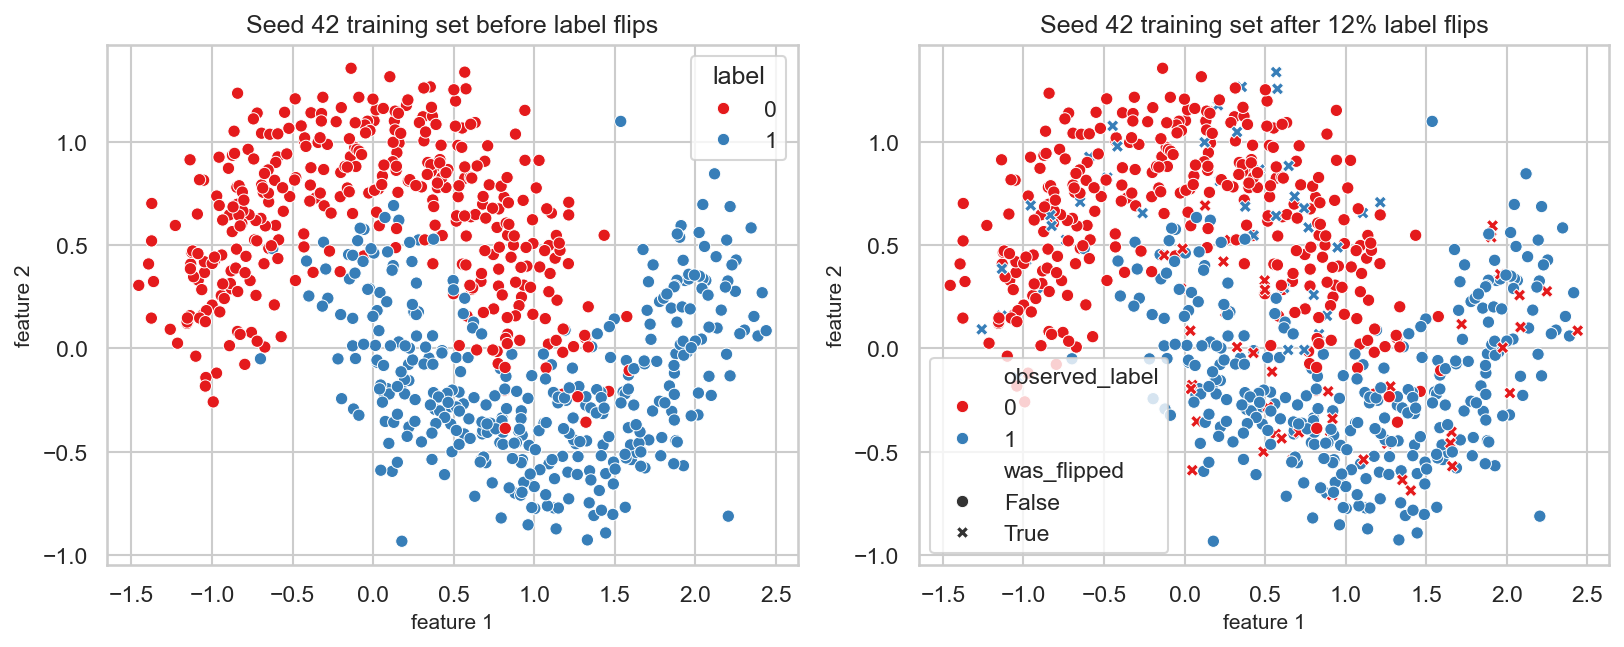

In [3]:
plot_dataset_overview(split, RESULTS_DIR / 'task_2_1_dataset_overview.png')

The figure makes the toy problem easy to inspect by eye. That matters here because the paper is not just about overall accuracy; it is specifically about what happens when some points end up so far on the wrong side of the boundary that continuing to chase them is counterproductive.

In [4]:
gamma_runs, gamma_summary = validate_gamma()
gamma_summary = gamma_summary.sort_values('mean_val_accuracy', ascending=False).reset_index(drop=True)
gamma_summary

   gamma  mean_val_accuracy  std_val_accuracy  mean_val_auc
0    2.0           0.929167          0.010206      0.976694
1    1.0           0.912500          0.007217      0.964861
2    0.5           0.888333          0.009033      0.945958

This validation sweep chooses the RBF width from a very small grid instead of tuning many moving parts. `gamma = 2.0` gives the best average validation accuracy here, so I freeze that value for the rest of the submission and do not keep retuning it in later notebooks.